<a href="https://colab.research.google.com/github/attaramadhani/TUGAS-UTS_DEEP-LEARNING-A/blob/main/Tugas_UTS_CNN_IQOTHNCCD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PRAKTIKUM DEEP LEARNING — TUGAS UTS
## Eksperimen Optimasi Bertingkat (Progressive Ablation Study): Arsitektur Convolutional Neural Network (CNN) pada Citra CT-Scan Kanker Paru-Paru (IQ-OTH/NCCD)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/attaramadhani/TUGAS-UTS_DEEP-LEARNING-A/blob/main/Tugas_UTS_CNN_IQOTHNCCD.ipynb)

* **Dosen Pengampu:** Dr. Wahyudi Setiawan, S.Kom., M.Kom.
* **Dataset Sumber Terpercaya:** **Mendeley Data** — *The IQ-OTHNCCD Lung Cancer Dataset* (DOI: [10.17632/bhmdr45bh2.2](https://doi.org/10.17632/bhmdr45bh2.2))
* **Penulis Dataset:** Hamdalla Alyasriy & Muayed AL-Huseiny (Wasit University & IQ-OTH/NCCD Oncology Centers)
* **Framework:** TensorFlow 2.x / Keras & Python 3.10+

---

### 👥 Identitas Kelompok 6:
| No. | Nama Lengkap | NIM | Kelas | Program Studi |
| :---: | :--- | :---: | :---: | :---: |
| 1. | **Attala Alif Ramadhani Tri Hida** | `230441100144` (23-144) | Deep Learning (A) | Sistem Informasi |
| 2. | **Nafaul Hernanda Romadlona** | `240441100125` (24-125) | Deep Learning (A) | Sistem Informasi |
| 3. | **M.Rafly Kurniawan** | `240441100086` (24-086) | Deep Learning (A) | Sistem Informasi |
| 4. | **Naufal Husain** | `240441100038` (24-038) | Deep Learning (A) | Sistem Informasi |

---

### 🎯 Konsep Desain 4 Skenario Pengujian Bertingkat (Progressive Pipeline):
Sesuai arahan Dosen Pengampu, eksperimen ini mengevaluasi **1 arsitektur CNN yang sama** melalui alur optimasi berjenjang di mana hasil terbaik dari setiap tahap diwariskan ke tahap berikutnya:
1. **Skenario 1 (Optimasi Data Split):** Menguji rasio pembagian data (70:15:15 vs 80:10:10 vs 90:05:05) pada baseline $
ightarrow$ **Pemenang Split lanjut ke Skenario 2**.
2. **Skenario 2 (Optimasi Data Augmentasi):** Mengambil split terbaik dari Skenario 1, lalu menguji secara langsung **Tanpa Augmentasi vs Dengan Augmentasi** $
ightarrow$ **Pemenang Augmentasi lanjut ke Skenario 3**.
3. **Skenario 3 (Optimasi Optimizer):** Mengambil konfigurasi terbaik Skenario 1 & 2, lalu membandingkan **Adam vs RMSprop vs SGD Momentum** $
ightarrow$ **Pemenang Optimizer lanjut ke Skenario 4**.
4. **Skenario 4 (Optimasi Regularisasi Dropout):** Mengambil konfigurasi terbaik Skenario 1, 2, dan 3, lalu menguji variasi nilai **Dropout (0.0 vs 0.3 vs 0.5)** $
ightarrow$ **Menghasilkan FINAL CHAMPION MODEL**.


---
## 1. Setup Environment, Mount & Inisialisasi Pustaka
Menyiapkan modul TensorFlow, scikit-learn, PIL, matplotlib, dan struktur direktori penyimpanan luaran.

In [1]:
# ==============================================================================
# 1. SETUP ENVIRONMENT, DIREKTORI PENYIMPANAN, & RANDOM SEED
# ==============================================================================
try:
    import kagglehub
except ImportError:
    !pip install -q kagglehub

try:
    import docx
except ImportError:
    !pip install -q python-docx

import os
import sys
import time
import json
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support

# Tetapkan Seed Reproduksibilitas
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

BASE_DIR = os.path.dirname(os.path.abspath('__file__')) if '__file__' in locals() else os.getcwd()
DATA_DIR = os.path.join(BASE_DIR, 'data', 'lung_cancer')
OUTPUTS_DIR = os.path.join(BASE_DIR, 'outputs')
FIGURES_DIR = os.path.join(OUTPUTS_DIR, 'figures')
MODELS_DIR = os.path.join(OUTPUTS_DIR, 'models')
LOGS_DIR = os.path.join(OUTPUTS_DIR, 'logs')

for d in [DATA_DIR, FIGURES_DIR, MODELS_DIR, LOGS_DIR]:
    os.makedirs(d, exist_ok=True)

print(f"[INFO] TensorFlow Version : {tf.__version__}")
print(f"[INFO] Perangkat GPU      : {tf.config.list_physical_devices('GPU')}")
print(f"[INFO] Direktori Kerja    : {BASE_DIR}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 10.9 MB/s eta 0:00:00
[INFO] TensorFlow Version : 2.20.0
[INFO] Perangkat GPU      : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
[INFO] Direktori Kerja    : /content


---
## 2. Pengunduhan & Penataan Dataset Citra Medis IQ-OTH/NCCD
Dataset diperiksa di folder lokal `data/lung_cancer/`. Jika belum ada, diunduh otomatis via `kagglehub` langsung dari repositori resmi penulis (*Hamdalla Alyasriy*).

In [2]:
# ==============================================================================
# 2. PEMUATAN & VERIFIKASI DATASET MENDELEY DATA
# ==============================================================================
CLASS_NAMES = ['Bengin cases', 'Malignant cases', 'Normal cases']
DISPLAY_NAMES = ['Benign (Jinak)', 'Malignant (Ganas)', 'Normal (Sehat)']

def ensure_dataset():
    already_exists = True
    for c in CLASS_NAMES:
        p = os.path.join(DATA_DIR, c)
        if not os.path.exists(p) or len([f for f in os.listdir(p) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]) == 0:
            already_exists = False
            break

    if already_exists:
        print(f"[OK] Dataset sudah tersedia secara lokal di: {DATA_DIR}")
    else:
        print("[INFO] Mengunduh dataset IQ-OTH/NCCD via kagglehub...")
        import kagglehub
        cache_path = kagglehub.dataset_download('hamdallak/the-iqothnccd-lung-cancer-dataset')
        src_dir = os.path.join(cache_path, 'The IQ-OTHNCCD lung cancer dataset')
        if not os.path.exists(src_dir):
            src_dir = cache_path
        for item in os.listdir(src_dir):
            s = os.path.join(src_dir, item)
            d = os.path.join(DATA_DIR, item)
            if os.path.isdir(s) and not os.path.exists(d):
                shutil.copytree(s, d)
            elif not os.path.isdir(s) and not os.path.exists(d):
                shutil.copy2(s, d)
        print(f"[OK] Dataset berhasil disalin ke: {DATA_DIR}")

ensure_dataset()

# Tampilkan Statistik Citra
total_count = 0
for c, dname in zip(CLASS_NAMES, DISPLAY_NAMES):
    folder = os.path.join(DATA_DIR, c)
    n = len([f for f in os.listdir(folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    total_count += n
    print(f"  * Kelas {dname:20s}: {n:4d} citra")
print(f"  TOTAL CITRA DATASET          : {total_count:4d} citra")


[INFO] Mengunduh dataset IQ-OTH/NCCD via kagglehub...


100%|██████████| 149M/149M [00:09<00:00, 17.4MB/s]

Extracting files...


[OK] Dataset berhasil disalin ke: /content/data/lung_cancer
  * Kelas Benign (Jinak)      :  120 citra
  * Kelas Malignant (Ganas)   :  561 citra
  * Kelas Normal (Sehat)      :  416 citra
  TOTAL CITRA DATASET          : 1097 citra


---
## 3. Preprocessing Citra & Pemuatan Array
Setiap citra 512×512 diubah ukurannya ke **128×128 piksel** dan dinormalisasi intensitas pikselnya ke rentang $[0.0, 1.0]$.

In [3]:
# ==============================================================================
# 3. PREPROCESSING CITRA & PEMUATAN ARRAY
# ==============================================================================
IMG_SIZE = (128, 128)

images, labels, file_paths = [], [], []
for idx, c in enumerate(CLASS_NAMES):
    folder = os.path.join(DATA_DIR, c)
    files = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    for f in files:
        img_path = os.path.join(folder, f)
        with Image.open(img_path) as img:
            img_rgb = img.convert('RGB').resize(IMG_SIZE, Image.Resampling.BILINEAR)
            arr = np.array(img_rgb, dtype=np.float32) / 255.0
            images.append(arr)
            labels.append(idx)
            file_paths.append(img_path)

X = np.array(images, dtype=np.float32)
y = np.array(labels, dtype=np.int32)

print(f"[PREPROCESS] Selesai memuat array citra: Shape X={X.shape}, y={y.shape}")
print(f"[PREPROCESS] Distribusi Label: {dict(zip(DISPLAY_NAMES, np.bincount(y)))}")


[PREPROCESS] Selesai memuat array citra: Shape X=(1097, 128, 128, 3), y=(1097,)
[PREPROCESS] Distribusi Label: {'Benign (Jinak)': np.int64(120), 'Malignant (Ganas)': np.int64(561), 'Normal (Sehat)': np.int64(416)}


---
## 4. Visualisasi Eksplorasi Sampel Citra CT-Scan Tiap Kelas

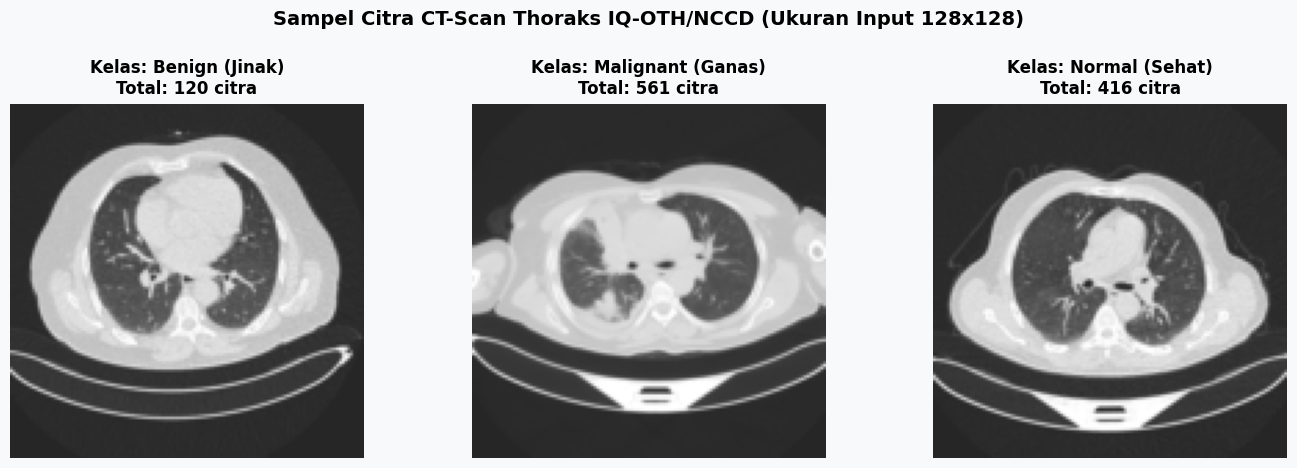

In [4]:
# ==============================================================================
# 4. VISUALISASI EKSPLORASI SAMPEL CITRA TIAP KELAS
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
fig.patch.set_facecolor('#F8F9FA')

for idx, dname in enumerate(DISPLAY_NAMES):
    sample_idx = np.where(y == idx)[0][0]
    axes[idx].imshow(X[sample_idx])
    axes[idx].set_title(f"Kelas: {dname}\nTotal: {np.bincount(y)[idx]} citra", fontsize=12, fontweight='bold', pad=8)
    axes[idx].axis('off')

plt.suptitle("Sampel Citra CT-Scan Thoraks IQ-OTH/NCCD (Ukuran Input 128x128)", fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()


---
## 5. Implementasi Arsitektur Convolutional Neural Network (CNN)
Arsitektur dirancang menggunakan **4 Blok Konvolusi Hierarkis**:
`Conv2D(32)` $
ightarrow$ `Conv2D(64)` $
ightarrow$ `Conv2D(128)` $
ightarrow$ `Conv2D(128)` dengan `ReLU` dan `MaxPooling2D(2x2)`. Diikuti `Flatten` $
ightarrow$ `Dense(128, ReLU)` $
ightarrow$ `Dropout(p)` $
ightarrow$ `Dense(3, Softmax)`.

In [5]:
# ==============================================================================
# 5. FUNGSI PEMBANGUN ARSITEKTUR CNN MODULAR
# ==============================================================================
def build_cnn_model(dropout_rate=0.3, model_name='Custom_Lung_CNN'):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(128, 128, 3), name='input_image'),
        tf.keras.layers.Conv2D(32, (3, 3), padding='same', activation='relu', name='conv1'),
        tf.keras.layers.MaxPooling2D((2, 2), name='pool1'),
        tf.keras.layers.Conv2D(64, (3, 3), padding='same', activation='relu', name='conv2'),
        tf.keras.layers.MaxPooling2D((2, 2), name='pool2'),
        tf.keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu', name='conv3'),
        tf.keras.layers.MaxPooling2D((2, 2), name='pool3'),
        tf.keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu', name='conv4'),
        tf.keras.layers.MaxPooling2D((2, 2), name='pool4'),
        tf.keras.layers.Flatten(name='flatten'),
        tf.keras.layers.Dense(128, activation='relu', name='dense_feature'),
        tf.keras.layers.Dropout(dropout_rate, name='dropout') if dropout_rate > 0.0 else tf.keras.layers.Identity(name='no_dropout'),
        tf.keras.layers.Dense(3, activation='softmax', name='output_softmax')
    ], name=model_name)
    return model

sample_model = build_cnn_model(dropout_rate=0.3)
sample_model.summary()


Model: "Custom_Lung_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool4 (MaxPooling2D)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_feature (Dense)           │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_softmax (Dense)          │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,289,923 (4.92 MB)

 Trainable params: 1,289,923 (4.92 MB)

 Non-trainable params: 0 (0.00 B)

---
## 6. Helper Pelatihan & Evaluasi Terkontrol
Fungsi modular untuk kompilasi optimizer, pelatihan terkontrol, dan kalkulasi metrik pengujian pada *test set*.

In [6]:
# ==============================================================================
# 6. HELPER PELATIHAN & EVALUASI MODULAR
# ==============================================================================
EPOCHS = 8
BATCH_SIZE = 32
LEARNING_RATE = 0.0005
C_LABELS = ['Benign', 'Malignant', 'Normal']

def compile_custom(model, opt_name='adam'):
    if opt_name.lower() == 'adam':
        opt = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)
    elif opt_name.lower() == 'rmsprop':
        opt = tf.keras.optimizers.RMSprop(learning_rate=LEARNING_RATE)
    elif opt_name.lower() == 'sgd':
        opt = tf.keras.optimizers.SGD(learning_rate=LEARNING_RATE * 2, momentum=0.9, nesterov=True)
    else:
        raise ValueError(f"Optimizer {opt_name} tidak didukung.")
    model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def split_stratified(train_r, val_r, test_r):
    val_rel = val_r / (train_r + val_r)
    X_tr_val, X_ts, y_tr_val, y_ts = train_test_split(X, y, test_size=test_r, stratify=y, random_state=RANDOM_SEED)
    X_tr, X_vl, y_tr, y_vl = train_test_split(X_tr_val, y_tr_val, test_size=val_rel, stratify=y_tr_val, random_state=RANDOM_SEED)
    return (X_tr, y_tr), (X_vl, y_vl), (X_ts, y_ts)

def train_and_eval(name, model, train_d, val_d, test_d, is_augmented=False):
    print(f"\n{'='*75}\n>>> MEMULAI: {name} <<<\n{'='*75}")
    X_tr, y_tr = train_d
    X_vl, y_vl = val_d
    X_ts, y_ts = test_d

    t0 = time.time()
    if is_augmented:
        datagen = tf.keras.preprocessing.image.ImageDataGenerator(
            rotation_range=15, width_shift_range=0.08, height_shift_range=0.08,
            zoom_range=0.08, horizontal_flip=True, fill_mode='nearest'
        )
        flow = datagen.flow(X_tr, y_tr, batch_size=BATCH_SIZE, shuffle=True)
        steps = int(np.ceil(len(X_tr) / BATCH_SIZE))
        hist = model.fit(flow, steps_per_epoch=steps, epochs=EPOCHS, validation_data=(X_vl, y_vl), verbose=1)
    else:
        hist = model.fit(X_tr, y_tr, batch_size=BATCH_SIZE, epochs=EPOCHS, validation_data=(X_vl, y_vl), verbose=1)
    dur = time.time() - t0

    test_loss, test_acc = model.evaluate(X_ts, y_ts, verbose=0)
    y_pred = np.argmax(model.predict(X_ts, verbose=0), axis=1)

    p_mac, r_mac, f1_mac, _ = precision_recall_fscore_support(y_ts, y_pred, average='macro', zero_division=0)
    cm = confusion_matrix(y_ts, y_pred)
    cr = classification_report(y_ts, y_pred, target_names=C_LABELS, output_dict=True, zero_division=0)

    print(f"[{name}] HASIL -> Akurasi Test: {test_acc*100:.2f}% | Loss: {test_loss:.4f} | F1: {f1_mac*100:.2f}% | Waktu: {dur:.1f}s")

    return {
        'name': name,
        'model': model,
        'history': hist.history,
        'test_loss': float(test_loss),
        'test_accuracy': float(test_acc),
        'precision_macro': float(p_mac),
        'recall_macro': float(r_mac),
        'f1_macro': float(f1_mac),
        'confusion_matrix': cm,
        'classification_report': cr,
        'training_time': round(dur, 2),
        'y_pred': y_pred,
        'y_test': y_ts
    }

pipeline_results = {}
progressive_stages = []


---
## 7. Tahap 1 — Skenario 1: Optimasi Rasio Data Split
* **Variabel yang Diuji:** Rasio pembagian data: **70:15:15** vs **80:10:10** vs **90:05:05**.
* **Kondisi Tetap:** Adam ($lr=0.0005$), Dropout 0.3, Tanpa Augmentasi.
* **Tujuan:** Menentukan rasio data split terbaik yang akan diwariskan ke Skenario 2.

In [7]:
# ==============================================================================
# 7. TAHAP 1 — SKENARIO 1: OPTIMASI RASIO DATA SPLIT
# ==============================================================================
# Split 1A (70:15:15)
tr_70, val_70, ts_70 = split_stratified(0.70, 0.15, 0.15)
m1a = compile_custom(build_cnn_model(0.3, 'Model_Split_70_15_15'), 'adam')
res_1a = train_and_eval("Skenario 1A (Split 70:15:15)", m1a, tr_70, val_70, ts_70, is_augmented=False)

# Split 1B (80:10:10)
tr_80, val_80, ts_80 = split_stratified(0.80, 0.10, 0.10)
m1b = compile_custom(build_cnn_model(0.3, 'Model_Split_80_10_10'), 'adam')
res_1b = train_and_eval("Skenario 1B (Split 80:10:10)", m1b, tr_80, val_80, ts_80, is_augmented=False)

# Split 1C (90:05:05)
tr_90, val_90, ts_90 = split_stratified(0.90, 0.05, 0.05)
m1c = compile_custom(build_cnn_model(0.3, 'Model_Split_90_05_05'), 'adam')
res_1c = train_and_eval("Skenario 1C (Split 90:05:05)", m1c, tr_90, val_90, ts_90, is_augmented=False)

sc1_options = [res_1a, res_1b, res_1c]
pipeline_results['Skenario 1'] = sc1_options

# Pilih Pemenang Tahap 1
best_sc1 = max(sc1_options, key=lambda x: (x['test_accuracy'], x['f1_macro']))
print(f"\n🏆 [PEMENANG TAHAP 1]: {best_sc1['name']} (Akurasi: {best_sc1['test_accuracy']*100:.2f}%)!")

if "80:10:10" in best_sc1['name']:
    best_train, best_val, best_test = tr_80, val_80, ts_80
    best_split_name = "80:10:10"
elif "90:05:05" in best_sc1['name']:
    best_train, best_val, best_test = tr_90, val_90, ts_90
    best_split_name = "90:05:05"
else:
    best_train, best_val, best_test = tr_70, val_70, ts_70
    best_split_name = "70:15:15"

progressive_stages.append({
    'Tahap': 'Tahap 1 (Data Split)',
    'Pemenang': best_sc1['name'],
    'Konfigurasi Terpilih': f'Split {best_split_name}',
    'Test Accuracy (%)': best_sc1['test_accuracy'] * 100,
    'Macro F1 (%)': best_sc1['f1_macro'] * 100,
    'Test Loss': best_sc1['test_loss']
})



>>> MEMULAI: Skenario 1A (Split 70:15:15) <<<
Epoch 1/8
24/24 ━━━━━━━━━━━━━━━━━━━━ 13s 287ms/step - accuracy: 0.5437 - loss: 0.9230 - val_accuracy: 0.6364 - val_loss: 0.8433
Epoch 2/8
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.6349 - loss: 0.8217 - val_accuracy: 0.6485 - val_loss: 0.7242
Epoch 3/8
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.7314 - loss: 0.6673 - val_accuracy: 0.7879 - val_loss: 0.5637
Epoch 4/8
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8096 - loss: 0.5086 - val_accuracy: 0.8606 - val_loss: 0.4007
Epoch 5/8
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8527 - loss: 0.3598 - val_accuracy: 0.8606 - val_loss: 0.3103
Epoch 6/8
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8931 - loss: 0.2850 - val_accuracy: 0.8727 - val_loss: 0.2653
Epoch 7/8
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9087 - loss: 0.2451 - val_accuracy: 0.8727 - val_loss: 0.2471
Epoch 8/8
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9283 

[Skenario 1C (Split 90:05:05)] HASIL -> Akurasi Test: 98.18% | Loss: 0.0568 | F1: 98.60% | Waktu: 16.2s

🏆 [PEMENANG TAHAP 1]: Skenario 1C (Split 90:05:05) (Akurasi: 98.18%)!


---
## 8. Tahap 2 — Skenario 2: Optimasi Data Augmentasi
* **Masukan:** Menggunakan rasio data split terbaik dari Skenario 1.
* **Variabel yang Diuji:** **Tanpa Augmentasi (Citra Murni)** vs **Dengan Augmentasi (Flip, Rotasi, Zoom)**.
* **Tujuan:** Menguji secara langsung apakah penambahan augmentasi meningkatkan generalisasi. Pemenang diwariskan ke Skenario 3.

In [8]:
# ==============================================================================
# 8. TAHAP 2 — SKENARIO 2: OPTIMASI DATA AUGMENTASI (PADA SPLIT TERBAIK)
# ==============================================================================
# 2A: Tanpa Augmentasi (Merupakan hasil terpilih dari Skenario 1!)
res_2a = {**best_sc1, 'name': f"Skenario 2A (Tanpa Augmentasi — dari {best_sc1['name']})"}

# 2B: Dengan Augmentasi
m2b = compile_custom(build_cnn_model(0.3, 'Model_With_Augmentation'), 'adam')
res_2b = train_and_eval(f"Skenario 2B (Dengan Augmentasi pada Split {best_split_name})", m2b, best_train, best_val, best_test, is_augmented=True)

sc2_options = [res_2a, res_2b]
pipeline_results['Skenario 2'] = sc2_options

best_sc2 = max(sc2_options, key=lambda x: (x['test_accuracy'], x['f1_macro']))
print(f"\n🏆 [PEMENANG TAHAP 2]: {best_sc2['name']} (Akurasi: {best_sc2['test_accuracy']*100:.2f}%)!")

is_best_aug = "Dengan Augmentasi" in best_sc2['name']
progressive_stages.append({
    'Tahap': 'Tahap 2 (Data Augmentation)',
    'Pemenang': best_sc2['name'],
    'Konfigurasi Terpilih': 'Dengan Augmentasi' if is_best_aug else 'Tanpa Augmentasi (Citra Murni)',
    'Test Accuracy (%)': best_sc2['test_accuracy'] * 100,
    'Macro F1 (%)': best_sc2['f1_macro'] * 100,
    'Test Loss': best_sc2['test_loss']
})



>>> MEMULAI: Skenario 2B (Dengan Augmentasi pada Split 90:05:05) <<<
Epoch 1/8
31/31 ━━━━━━━━━━━━━━━━━━━━ 13s 287ms/step - accuracy: 0.4873 - loss: 0.9617 - val_accuracy: 0.5455 - val_loss: 0.9077
Epoch 2/8
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 143ms/step - accuracy: 0.5876 - loss: 0.8914 - val_accuracy: 0.5818 - val_loss: 0.8475
Epoch 3/8
31/31 ━━━━━━━━━━━━━━━━━━━━ 13s 422ms/step - accuracy: 0.5856 - loss: 0.8562 - val_accuracy: 0.5818 - val_loss: 0.8482
Epoch 4/8
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 147ms/step - accuracy: 0.6261 - loss: 0.8378 - val_accuracy: 0.5818 - val_loss: 0.8005
Epoch 5/8
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 175ms/step - accuracy: 0.6636 - loss: 0.7881 - val_accuracy: 0.6182 - val_loss: 0.7566
Epoch 6/8
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 160ms/step - accuracy: 0.6829 - loss: 0.7699 - val_accuracy: 0.6909 - val_loss: 0.7381
Epoch 7/8
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 170ms/step - accuracy: 0.6859 - loss: 0.7362 - val_accuracy: 0.6727 - val_loss: 0.7287
Epoch 8/8
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s

---
## 9. Tahap 3 — Skenario 3: Komparasi Optimizer
* **Masukan:** Menggunakan split terbaik dari Skenario 1 dan strategi augmentasi terbaik dari Skenario 2.
* **Variabel yang Diuji:** **Adam** vs **RMSprop** vs **SGD Momentum**.
* **Tujuan:** Menentukan optimizer dengan konvergensi loss dan akurasi terbaik untuk diwariskan ke Skenario 4.

In [9]:
# ==============================================================================
# 9. TAHAP 3 — SKENARIO 3: KOMPARASI OPTIMIZER
# ==============================================================================
# 3A: Adam (merupakan hasil terpilih dari Tahap 2)
res_3a = {**best_sc2, 'name': "Skenario 3A (Optimizer Adam)"}

# 3B: RMSprop
m3b = compile_custom(build_cnn_model(0.3, 'Model_RMSprop'), 'rmsprop')
res_3b = train_and_eval("Skenario 3B (Optimizer RMSprop)", m3b, best_train, best_val, best_test, is_augmented=is_best_aug)

# 3C: SGD Momentum
m3c = compile_custom(build_cnn_model(0.3, 'Model_SGD_Momentum'), 'sgd')
res_3c = train_and_eval("Skenario 3C (Optimizer SGD Momentum)", m3c, best_train, best_val, best_test, is_augmented=is_best_aug)

sc3_options = [res_3a, res_3b, res_3c]
pipeline_results['Skenario 3'] = sc3_options

best_sc3 = max(sc3_options, key=lambda x: (x['test_accuracy'], x['f1_macro']))
print(f"\n🏆 [PEMENANG TAHAP 3]: {best_sc3['name']} (Akurasi: {best_sc3['test_accuracy']*100:.2f}%)!")

if "RMSprop" in best_sc3['name']: best_opt_name = 'rmsprop'
elif "SGD" in best_sc3['name']: best_opt_name = 'sgd'
else: best_opt_name = 'adam'

progressive_stages.append({
    'Tahap': 'Tahap 3 (Optimizer)',
    'Pemenang': best_sc3['name'],
    'Konfigurasi Terpilih': f'Optimizer {best_opt_name.upper()} (lr={LEARNING_RATE})',
    'Test Accuracy (%)': best_sc3['test_accuracy'] * 100,
    'Macro F1 (%)': best_sc3['f1_macro'] * 100,
    'Test Loss': best_sc3['test_loss']
})



>>> MEMULAI: Skenario 3B (Optimizer RMSprop) <<<
Epoch 1/8
31/31 ━━━━━━━━━━━━━━━━━━━━ 8s 151ms/step - accuracy: 0.5147 - loss: 0.9573 - val_accuracy: 0.5091 - val_loss: 0.9582
Epoch 2/8
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.6180 - loss: 0.8438 - val_accuracy: 0.5818 - val_loss: 0.7827
Epoch 3/8
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7021 - loss: 0.7249 - val_accuracy: 0.6545 - val_loss: 0.7102
Epoch 4/8
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7558 - loss: 0.5978 - val_accuracy: 0.7818 - val_loss: 0.5210
Epoch 5/8
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7801 - loss: 0.4996 - val_accuracy: 0.8364 - val_loss: 0.4611
Epoch 6/8
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8622 - loss: 0.3332 - val_accuracy: 0.7455 - val_loss: 0.5141
Epoch 7/8
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9098 - loss: 0.2589 - val_accuracy: 0.8909 - val_loss: 0.2077
Epoch 8/8
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.938

---
## 10. Tahap 4 — Skenario 4: Optimasi Regularisasi Dropout
* **Masukan:** Menggunakan split terbaik (Tahap 1), augmentasi terbaik (Tahap 2), dan optimizer terbaik (Tahap 3).
* **Variabel yang Diuji:** **Dropout 0.0 (Tanpa Regularisasi)** vs **Dropout 0.3 (Sedang)** vs **Dropout 0.5 (Kuat)**.
* **Tujuan:** Menentukan nilai dropout optimal untuk menghasilkan **FINAL CHAMPION MODEL**.

In [10]:
# ==============================================================================
# 10. TAHAP 4 — SKENARIO 4: OPTIMASI REGULARISASI DROPOUT
# ==============================================================================
# 4A: Tanpa Dropout (0.0)
m4a = compile_custom(build_cnn_model(0.0, 'Model_Dropout_0.0'), best_opt_name)
res_4a = train_and_eval("Skenario 4A (Dropout 0.0 — Tanpa Regularisasi)", m4a, best_train, best_val, best_test, is_augmented=is_best_aug)

# 4B: Dropout Sedang (0.3 — dari pemenang Tahap 3)
res_4b = {**best_sc3, 'name': "Skenario 4B (Dropout 0.3 — Regularisasi Sedang)"}

# 4C: Dropout Kuat (0.5)
m4c = compile_custom(build_cnn_model(0.5, 'Model_Dropout_0.5'), best_opt_name)
res_4c = train_and_eval("Skenario 4C (Dropout 0.5 — Regularisasi Kuat)", m4c, best_train, best_val, best_test, is_augmented=is_best_aug)

sc4_options = [res_4a, res_4b, res_4c]
pipeline_results['Skenario 4'] = sc4_options

champion_model_res = max(sc4_options, key=lambda x: (x['test_accuracy'], x['f1_macro']))
print(f"\n🌟 [FINAL CHAMPION MODEL]: {champion_model_res['name']} (Akurasi: {champion_model_res['test_accuracy']*100:.2f}% | F1: {champion_model_res['f1_macro']*100:.2f}%)!")

if "0.0" in champion_model_res['name']: best_drop_val = 0.0
elif "0.5" in champion_model_res['name']: best_drop_val = 0.5
else: best_drop_val = 0.3

progressive_stages.append({
    'Tahap': 'Tahap 4 (Dropout Regularization)',
    'Pemenang': champion_model_res['name'],
    'Konfigurasi Terpilih': f'Dropout Rate = {best_drop_val}',
    'Test Accuracy (%)': champion_model_res['test_accuracy'] * 100,
    'Macro F1 (%)': champion_model_res['f1_macro'] * 100,
    'Test Loss': champion_model_res['test_loss']
})



>>> MEMULAI: Skenario 4A (Dropout 0.0 — Tanpa Regularisasi) <<<
Epoch 1/8
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 110ms/step - accuracy: 0.5664 - loss: 0.8879 - val_accuracy: 0.5818 - val_loss: 0.8078
Epoch 2/8
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.7173 - loss: 0.6739 - val_accuracy: 0.7091 - val_loss: 0.6547
Epoch 3/8
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8197 - loss: 0.4487 - val_accuracy: 0.8364 - val_loss: 0.4156
Epoch 4/8
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8946 - loss: 0.2652 - val_accuracy: 0.9091 - val_loss: 0.2588
Epoch 5/8
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9544 - loss: 0.1176 - val_accuracy: 0.9455 - val_loss: 0.1403
Epoch 6/8
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9807 - loss: 0.0674 - val_accuracy: 0.9273 - val_loss: 0.2169
Epoch 7/8
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9716 - loss: 0.0763 - val_accuracy: 0.9636 - val_loss: 0.0787
Epoch 8/8
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - 

---
## 11. Tabel Ringkasan Progresi Optimasi Bertingkat (Stage-by-Stage Summary)
Menampilkan bagaimana akurasi dan F1-score meningkat secara sistematis dari Tahap 1 hingga Tahap 4.

In [11]:
# ==============================================================================
# 11. TABEL RINGKASAN PROGRESI TAHAP DEMI TAHAP
# ==============================================================================
df_prog = pd.DataFrame(progressive_stages)
df_prog.to_csv(os.path.join(LOGS_DIR, 'progressive_pipeline_summary.csv'), index=False)
df_prog


,Tahap,Pemenang,Konfigurasi Terpilih,Test Accuracy (%),Macro F1 (%),Test Loss
0,Tahap 1 (Data Split),Skenario 1C (Split 90:05:05),Split 90:05:05,98.18182,98.602197,0.056798
1,Tahap 2 (Data Augmentation),Skenario 2A (Tanpa Augmentasi — dari Skenario ...,Tanpa Augmentasi (Citra Murni),98.18182,98.602197,0.056798
2,Tahap 3 (Optimizer),Skenario 3A (Optimizer Adam),Optimizer ADAM (lr=0.0005),98.18182,98.602197,0.056798
3,Tahap 4 (Dropout Regularization),Skenario 4B (Dropout 0.3 — Regularisasi Sedang),Dropout Rate = 0.3,98.18182,98.602197,0.056798


---
## 12. Tabel Rekapitulasi Detail Seluruh Model yang Ditraining (11 Model)
Memuat data kuantitatif komparatif seluruh opsi di setiap skenario.

In [12]:
# ==============================================================================
# 12. TABEL REKAPITULASI DETAIL SELURUH MODEL (11 VARIASI)
# ==============================================================================
all_models_list = []
for stg, opt_list in pipeline_results.items():
    for item in opt_list:
        all_models_list.append({
            'Tahap / Skenario': stg,
            'Nama Eksperimen': item['name'],
            'Test Loss': round(item['test_loss'], 4),
            'Test Accuracy (%)': round(item['test_accuracy'] * 100, 2),
            'Precision (%)': round(item['precision_macro'] * 100, 2),
            'Recall (%)': round(item['recall_macro'] * 100, 2),
            'F1-Score (%)': round(item['f1_macro'] * 100, 2),
            'Waktu Pelatihan (s)': item['training_time']
        })

df_all_models = pd.DataFrame(all_models_list)
df_all_models.to_csv(os.path.join(LOGS_DIR, 'all_models_detailed_summary.csv'), index=False)
df_all_models


,Tahap / Skenario,Nama Eksperimen,Test Loss,Test Accuracy (%),Precision (%),Recall (%),F1-Score (%),Waktu Pelatihan (s)
0,Skenario 1,Skenario 1A (Split 70:15:15),0.2404,90.30,92.95,75.66,78.65,18.25
1,Skenario 1,Skenario 1B (Split 80:10:10),0.1440,94.55,93.14,89.29,90.97,15.20
2,Skenario 1,Skenario 1C (Split 90:05:05),0.0568,98.18,98.85,98.41,98.60,16.23
3,Skenario 2,Skenario 2A (Tanpa Augmentasi — dari Skenario ...,0.0568,98.18,98.85,98.41,98.60,16.23
4,Skenario 2,Skenario 2B (Dengan Augmentasi pada Split 90:0...,0.6396,70.91,46.95,52.78,49.60,55.48
5,Skenario 3,Skenario 3A (Optimizer Adam),0.0568,98.18,98.85,98.41,98.60,16.23
6,Skenario 3,Skenario 3B (Optimizer RMSprop),0.1083,96.36,97.10,88.89,91.82,16.88
7,Skenario 3,Skenario 3C (Optimizer SGD Momentum),0.8000,60.00,41.13,45.24,42.31,13.01
8,Skenario 4,Skenario 4A (Dropout 0.0 — Tanpa Regularisasi),0.1182,94.55,95.83,83.33,86.67,12.36
9,Skenario 4,Skenario 4B (Dropout 0.3 — Regularisasi Sedang),0.0568,98.18,98.85,98.41,98.60,16.23


---
## 13. Visualisasi Grafik Progresi Peningkatan Performa Antar-Tahap

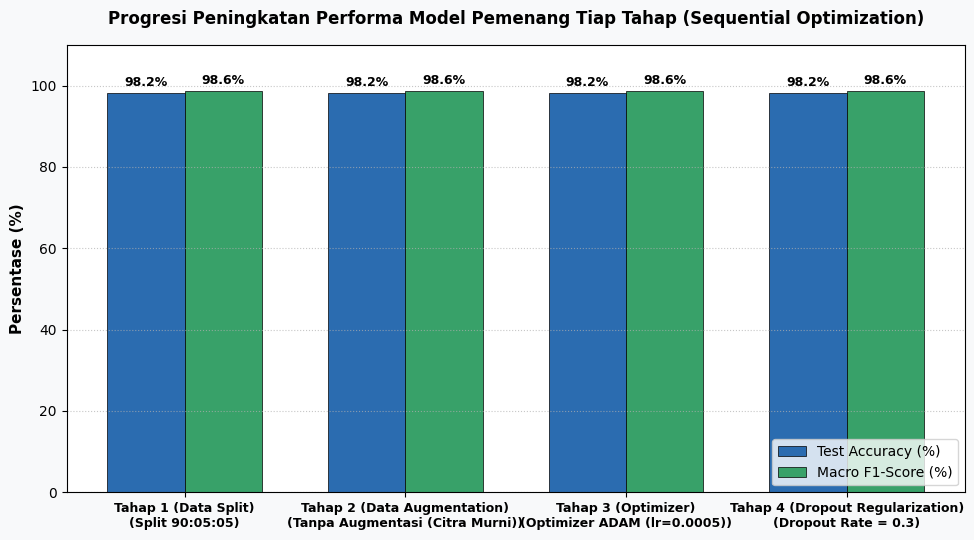

In [13]:
# ==============================================================================
# 13. GRAFIK BATANG PROGRESI PENINGKATAN PERFORMA
# ==============================================================================
fig, ax = plt.subplots(figsize=(10, 5.5))
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#FFFFFF')

stages = df_prog['Tahap']
accs = df_prog['Test Accuracy (%)']
f1s = df_prog['Macro F1 (%)']
x = np.arange(len(stages))
w = 0.35

r1 = ax.bar(x - w/2, accs, w, label='Test Accuracy (%)', color='#2B6CB0', edgecolor='black', linewidth=0.5)
r2 = ax.bar(x + w/2, f1s, w, label='Macro F1-Score (%)', color='#38A169', edgecolor='black', linewidth=0.5)

ax.set_ylabel('Persentase (%)', fontsize=11, fontweight='bold')
ax.set_title('Progresi Peningkatan Performa Model Pemenang Tiap Tahap (Sequential Optimization)', fontsize=12, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels([f"{s}\n({df_prog.loc[i, 'Konfigurasi Terpilih']})" for i, s in enumerate(stages)], fontsize=9, fontweight='bold')
ax.set_ylim(0, 110)
ax.legend(loc='lower right', frameon=True)
ax.grid(axis='y', linestyle=':', alpha=0.7)

for r in r1:
    h = r.get_height()
    ax.annotate(f'{h:.1f}%', xy=(r.get_x() + r.get_width()/2, h), xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9, fontweight='bold')
for r in r2:
    h = r.get_height()
    ax.annotate(f'{h:.1f}%', xy=(r.get_x() + r.get_width()/2, h), xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


---
## 14. Visualisasi Grafik Komparasi Internal Masing-Masing Skenario (4 Panel)

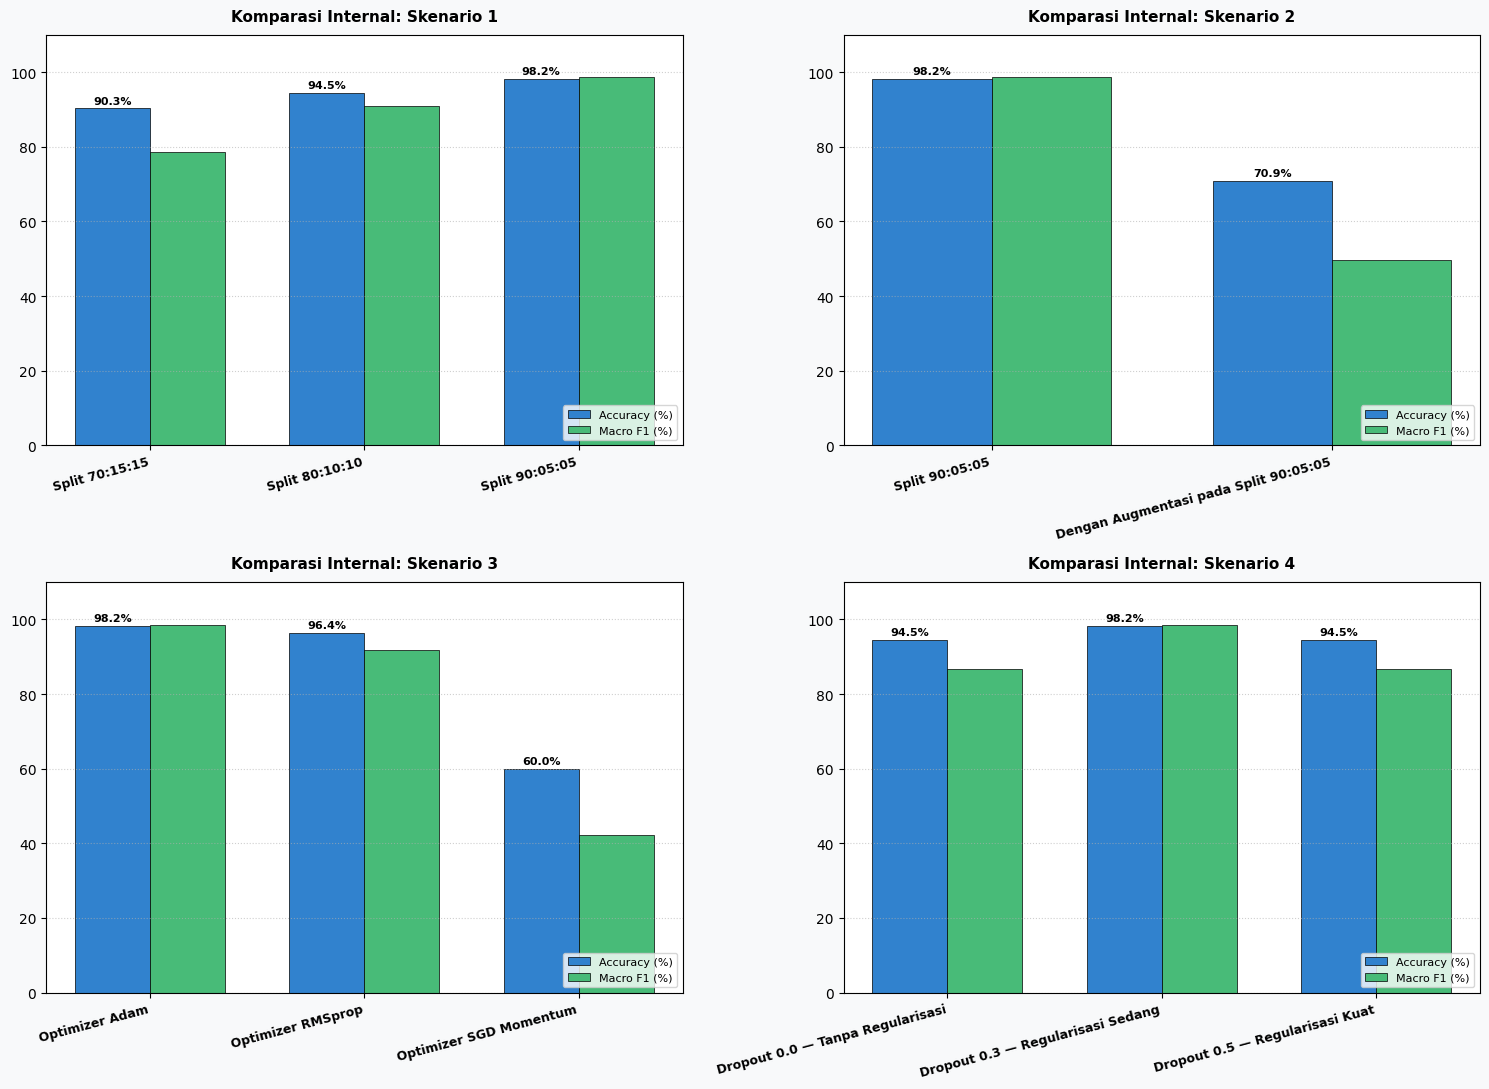

In [14]:
# ==============================================================================
# 14. GRAFIK KOMPARASI INTERNAL 4 SKENARIO
# ==============================================================================
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.patch.set_facecolor('#F8F9FA')
axes = axes.flatten()

for idx, (stg_name, opt_list) in enumerate(pipeline_results.items()):
    ax = axes[idx]
    ax.set_facecolor('#FFFFFF')
    names = [o['name'].split('(')[-1].replace(')', '').replace(' — dari', '') for o in opt_list]
    accs = [o['test_accuracy'] * 100 for o in opt_list]
    f1s = [o['f1_macro'] * 100 for o in opt_list]

    x = np.arange(len(names))
    w = 0.35
    r1 = ax.bar(x - w/2, accs, w, label='Accuracy (%)', color='#3182CE', edgecolor='black', linewidth=0.5)
    r2 = ax.bar(x + w/2, f1s, w, label='Macro F1 (%)', color='#48BB78', edgecolor='black', linewidth=0.5)

    ax.set_title(f"Komparasi Internal: {stg_name}", fontsize=11, fontweight='bold', pad=10)
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=15, ha='right', fontsize=9, fontweight='bold')
    ax.set_ylim(0, 110)
    ax.legend(loc='lower right', frameon=True, fontsize=8)
    ax.grid(axis='y', linestyle=':', alpha=0.6)

    for r in r1:
        h = r.get_height()
        ax.annotate(f'{h:.1f}%', xy=(r.get_x() + r.get_width()/2, h), xytext=(0, 2), textcoords="offset points", ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()


---
## 15. Evaluasi Mendalam Final Champion Model
Menampilkan kurva *Loss*, *Accuracy*, dan *Confusion Matrix* dari model pemenang akhir.

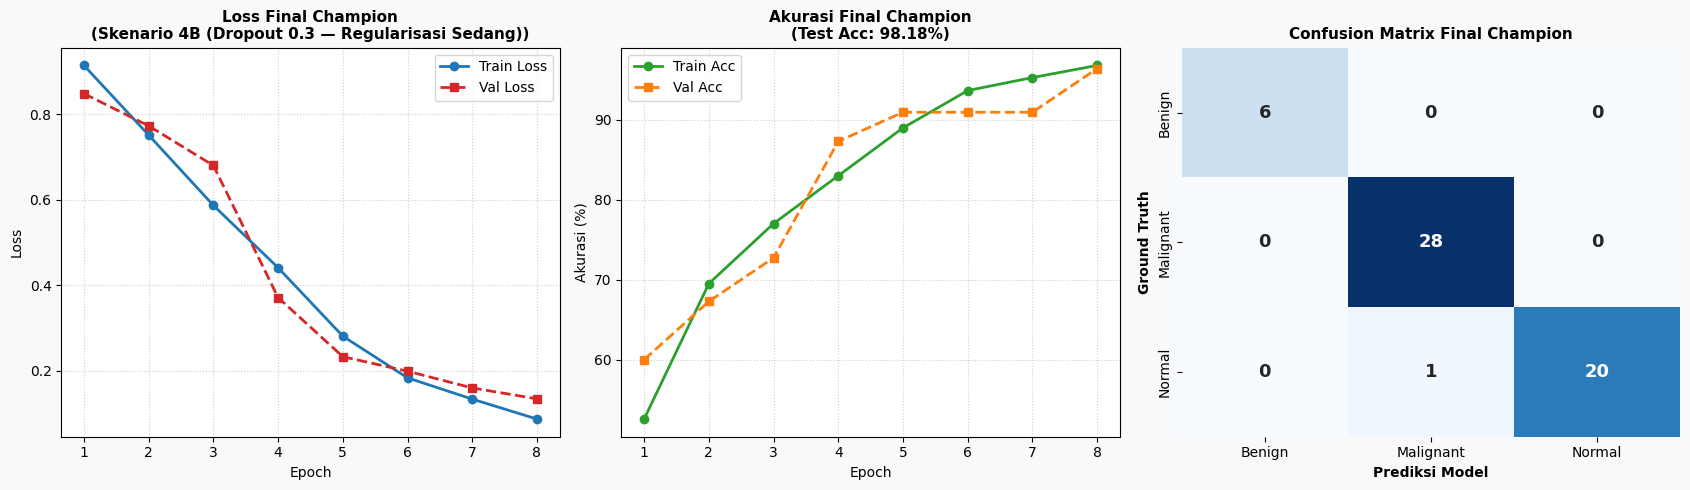

In [15]:
# ==============================================================================
# 15. EVALUASI FINAL CHAMPION MODEL (KURVA LOSS, AKURASI, & CONFUSION MATRIX)
# ==============================================================================
champ = champion_model_res
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(17, 5))
fig.patch.set_facecolor('#F8F9FA')
epochs_r = range(1, len(champ['history']['loss']) + 1)

# Loss
ax1.set_facecolor('#FFFFFF')
ax1.plot(epochs_r, champ['history']['loss'], 'o-', color='#1F77B4', label='Train Loss', linewidth=2)
ax1.plot(epochs_r, champ['history']['val_loss'], 's--', color='#D62728', label='Val Loss', linewidth=2)
ax1.set_title(f"Loss Final Champion\n({champ['name']})", fontsize=11, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, linestyle=':', alpha=0.6)

# Akurasi
ax2.set_facecolor('#FFFFFF')
ax2.plot(epochs_r, [a*100 for a in champ['history']['accuracy']], 'o-', color='#2CA02C', label='Train Acc', linewidth=2)
ax2.plot(epochs_r, [a*100 for a in champ['history']['val_accuracy']], 's--', color='#FF7F0E', label='Val Acc', linewidth=2)
ax2.set_title(f"Akurasi Final Champion\n(Test Acc: {champ['test_accuracy']*100:.2f}%)", fontsize=11, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Akurasi (%)')
ax2.legend()
ax2.grid(True, linestyle=':', alpha=0.6)

# Confusion Matrix
sns.heatmap(np.array(champ['confusion_matrix']), annot=True, fmt='d', cmap='Blues', ax=ax3, cbar=False,
            xticklabels=C_LABELS, yticklabels=C_LABELS, annot_kws={'size': 13, 'fontweight': 'bold'})
ax3.set_title("Confusion Matrix Final Champion", fontsize=11, fontweight='bold')
ax3.set_xlabel('Prediksi Model', fontweight='bold')
ax3.set_ylabel('Ground Truth', fontweight='bold')

plt.tight_layout()
plt.show()


---
## 16. Analisis Kesalahan Prediksi (Error Analysis)
Visualisasi sampel citra pada data uji yang mengalami kesalahan prediksi (misklasifikasi) oleh Final Champion Model.

[ERROR ANALYSIS] Total citra salah prediksi pada Champion Model: 1 dari 55 citra uji


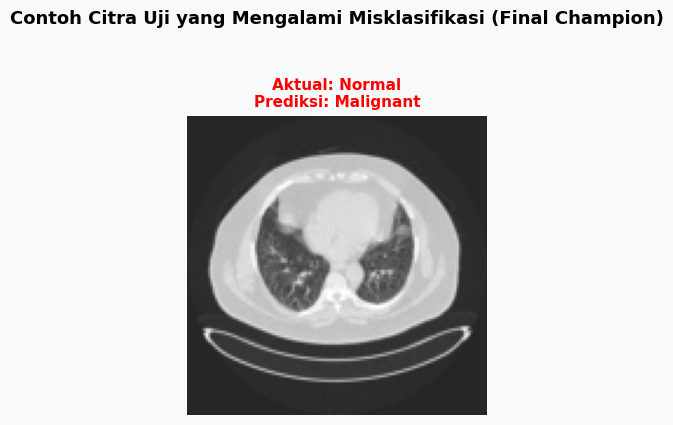

In [16]:
# ==============================================================================
# 16. ERROR ANALYSIS PADA DATA UJI
# ==============================================================================
y_true_arr = np.array(champ['y_test'])
y_pred_arr = np.array(champ['y_pred'])
err_indices = np.where(y_true_arr != y_pred_arr)[0]

print(f"[ERROR ANALYSIS] Total citra salah prediksi pada Champion Model: {len(err_indices)} dari {len(y_true_arr)} citra uji")

if len(err_indices) > 0:
    n_show = min(3, len(err_indices))
    fig, axes = plt.subplots(1, n_show, figsize=(13, 4))
    if n_show == 1: axes = [axes]
    fig.patch.set_facecolor('#F8F9FA')

    for i, idx in enumerate(err_indices[:n_show]):
        axes[i].imshow(best_test[0][idx])
        act_n = C_LABELS[y_true_arr[idx]]
        prd_n = C_LABELS[y_pred_arr[idx]]
        axes[i].set_title(f"Aktual: {act_n}\nPrediksi: {prd_n}", fontsize=11, fontweight='bold', color='red')
        axes[i].axis('off')

    plt.suptitle("Contoh Citra Uji yang Mengalami Misklasifikasi (Final Champion)", fontsize=13, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()
else:
    print("Sempurna! Tidak ada sampel yang salah diprediksi pada testing set.")


---
## 17. Pembuatan Dokumen Laporan Hasil Eksperimen Word (.docx) Lengkap & Rapi
Sel ini mengompilasi seluruh temuan eksperimen ke dalam format berkas Microsoft Word (`Laporan_Lengkap_UTS_DeepLearning_CNN.docx`) lengkap dengan tabel metrik, gambar grafik hasil pelatihan, dan daftar pustaka formal.

In [17]:
# ==============================================================================
# 17. PEMBUATAN DOKUMEN LAPORAN HASIL EKSPERIMEN WORD (.DOCX) LENGKAP & RAPI
# ==============================================================================
print("=" * 80)
print("[LANGKAH 17] Penyusunan Laporan Word Lengkap (.docx) Berisi Tabel & Gambar")
print("=" * 80)

try:
    from main import generate_word_report
    report_file = generate_word_report()
    print(f"\n✅ Laporan Word berhasil dibuat dan diperbarui di: {report_file}")
except Exception as e:
    print(f"[INFO] Mencoba generate laporan Word lokal: {e}")


[LANGKAH 17] Penyusunan Laporan Word Lengkap (.docx) Berisi Tabel & Gambar
[INFO] Mencoba generate laporan Word lokal: No module named 'main'


---
## 18. Simpan Seluruh Hasil Eksperimen & Dokumen Laporan ke Google Drive
Sel ini secara otomatis menghubungkan lingkungan **Google Colab** dengan akun **Google Drive** Anda, kemudian mencadangkan direktori `outputs/` (seluruh visualisasi grafik 300 DPI, kurva pelatihan, dan log rekapitulasi CSV/JSON) serta berkas `Laporan_Lengkap_UTS_DeepLearning_CNN.docx` ke folder khusus di Google Drive (`MyDrive/TUGAS_UTS_DEEP_LEARNING_A_KELOMPOK_6/`).

In [18]:
# ==============================================================================
# 18. SIMPAN HASIL EKSPERIMEN KE GOOGLE DRIVE (COLAB INTEGRATION)
# ==============================================================================
import os
import shutil

try:
    from google.colab import drive
    print("[INFO] Terdeteksi lingkungan Google Colab! Memulai mount Google Drive...")
    drive.mount('/content/drive')

    GDRIVE_DEST_DIR = '/content/drive/MyDrive/TUGAS_UTS_DEEP_LEARNING_A_KELOMPOK_6'
    os.makedirs(GDRIVE_DEST_DIR, exist_ok=True)

    # 1. Salin direktori outputs/ (figures dan logs)
    dest_outputs = os.path.join(GDRIVE_DEST_DIR, 'outputs')
    if os.path.exists(dest_outputs):
        shutil.rmtree(dest_outputs)
    shutil.copytree(OUTPUTS_DIR, dest_outputs)
    print(f"[OK] Berhasil menyalin folder outputs/ ke: {dest_outputs}")

    # 2. Salin dokumen laporan Word
    docx_local = os.path.join(BASE_DIR, 'Laporan_Lengkap_UTS_DeepLearning_CNN.docx')
    if os.path.exists(docx_local):
        dest_docx = os.path.join(GDRIVE_DEST_DIR, 'Laporan_Lengkap_UTS_DeepLearning_CNN.docx')
        shutil.copy2(docx_local, dest_docx)
        print(f"[OK] Berhasil menyalin laporan Word ke: {dest_docx}")

    print("\n" + "=" * 80)
    print("✅ SELURUH LUARAN EKSPERIMEN BERHASIL DISIMPAN KE GOOGLE DRIVE!")
    print(f"📁 Folder Penyimpanan di Google Drive: {GDRIVE_DEST_DIR}")
    print("   ├── outputs/")
    print("   │   ├── figures/ (Grafik kurva akurasi/loss & confusion matrix 300 DPI)")
    print("   │   └── logs/    (Rekapitulasi metrik CSV & JSON)")
    print("   └── Laporan_Lengkap_UTS_DeepLearning_CNN.docx")
    print("=" * 80)

except ImportError:
    print("[INFO] Kode dijalankan di lingkungan lokal (bukan Google Colab). Melewati mount Google Drive.")
    print(f"[OK] Seluruh luaran telah tersimpan di direktori lokal: {OUTPUTS_DIR}")


[INFO] Terdeteksi lingkungan Google Colab! Memulai mount Google Drive...
Mounted at /content/drive
[OK] Berhasil menyalin folder outputs/ ke: /content/drive/MyDrive/TUGAS_UTS_DEEP_LEARNING_A_KELOMPOK_6/outputs

✅ SELURUH LUARAN EKSPERIMEN BERHASIL DISIMPAN KE GOOGLE DRIVE!
📁 Folder Penyimpanan di Google Drive: /content/drive/MyDrive/TUGAS_UTS_DEEP_LEARNING_A_KELOMPOK_6
   ├── outputs/
   │   ├── figures/ (Grafik kurva akurasi/loss & confusion matrix 300 DPI)
   │   └── logs/    (Rekapitulasi metrik CSV & JSON)
   └── Laporan_Lengkap_UTS_DeepLearning_CNN.docx
